Cell 1 — Install Dependencies

In [1]:
!pip install torch torchvision pytorch-lightning scikit-learn matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 17.0 MB/s eta 0:00:00


Cell 2 — Imports

In [2]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.utils.data import DataLoader, TensorDataset
from mpl_toolkits.mplot3d import Axes3D

torch.manual_seed(42)
np.random.seed(42)

Cell 3 — Generate Synthetic 3-Variable Nonlinear Data

Same equation as previous parts:
y=sin(x1​)+x22​+log(x32​+1)

In [3]:
N = 1000

x1 = np.random.uniform(-3, 3, N)
x2 = np.random.uniform(-2, 2, N)
x3 = np.random.uniform(-2, 2, N)

X = np.stack([x1, x2, x3], axis=1).astype(np.float32)
y = (np.sin(x1) + x2**2 + np.log(x3**2 + 1)).astype(np.float32)

X_tensor = torch.tensor(X)
y_tensor = torch.tensor(y).view(-1,1)

dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

Cell 4 — Define Lightning Module

Architecture:

Input: 3

Hidden1: 64 (ReLU)

Hidden2: 32 (Tanh)

Hidden3: 16 (ReLU)

Output: 1 (Linear)

In [4]:
class LightningRegression(pl.LightningModule):
    def __init__(self):
        super().__init__()

        self.layer1 = nn.Linear(3, 64)
        self.layer2 = nn.Linear(64, 32)
        self.layer3 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)

        self.criterion = nn.MSELoss()

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.tanh(self.layer2(x))
        x = torch.relu(self.layer3(x))
        x = self.output(x)
        return x

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        self.log("train_loss", loss)
        return loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

Cell 5 — Train Model

In [5]:
model = LightningRegression()

trainer = pl.Trainer(
    max_epochs=500,
    enable_progress_bar=False,
    logger=False
)

trainer.fit(model, dataloader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ layer1    │ Linear  │    256 │ train │     0 │
│ 1 │ layer2    │ Linear  │  2.1 K │ train │     0 │
│ 2 │ layer3    │ Linear  │    528 │ train │     0 │
│ 3 │ output    │ Linear  │     17 │ train │     0 │
│ 4 │ criterion │ MSELoss │      0 │ train │     0 │
└───┴───────────┴─────────┴────────┴───────┴───────┘

Trainable params: 2.9 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 2.9 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=500` reached.


Cell 6 — Evaluate Predictions

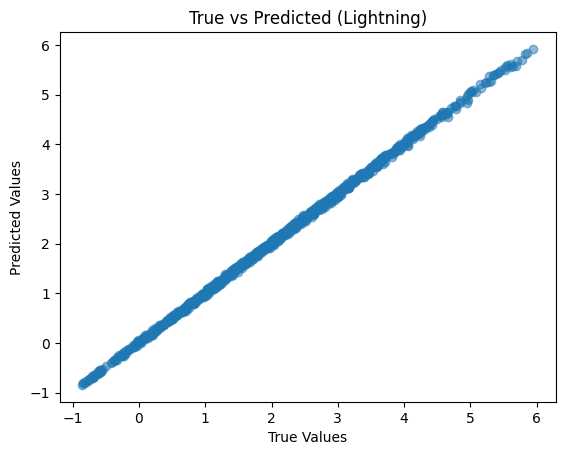

In [6]:
model.eval()
with torch.no_grad():
    preds = model(X_tensor)

plt.scatter(y, preds.numpy(), alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted (Lightning)")
plt.show()

Cell 7 — 4D Visualization (PCA Reduction)

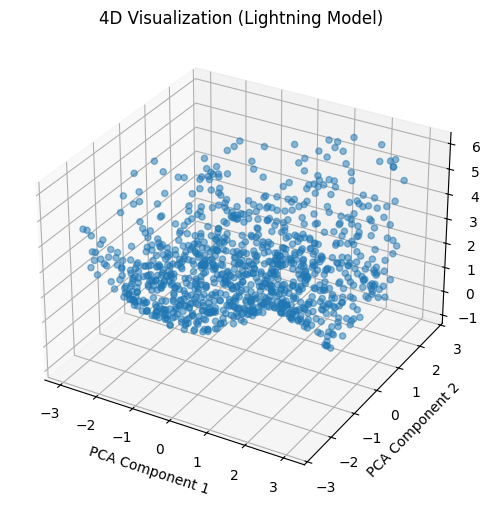

In [7]:
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_reduced[:,0], X_reduced[:,1], y, alpha=0.5)
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("Output")
plt.title("4D Visualization (Lightning Model)")
plt.show()